# Embedding+LSTM

## 1. 导入所需的库

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from collections import Counter
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"当前设备: {device}")

当前使用设备: cpu


## 2. 读取数据集

In [15]:
df = pd.read_csv('/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv')

print(df.head())
print(df['sentiment'].value_counts())

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


## 3. 数据清洗与预处理

In [17]:
import re
#Removes Punctuations
def remove_punctuations(data):
    punct_tag=re.compile(r'[^\w\s]')
    data=punct_tag.sub(r'',data)
    return data

#Removes HTML syntaxes
def remove_html(data):
    html_tag=re.compile(r'<.*?>')
    data=html_tag.sub(r'',data)
    return data

#Removes URL data
def remove_url(data):
    url_clean= re.compile(r"https://\S+|www\.\S+")
    data=url_clean.sub(r'',data)
    return data

#Removes Emojis
def remove_emoji(data):
    emoji_clean= re.compile("["
                           u"\U0001F600-\U0001F64F"  # emoticons
                           u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                           u"\U0001F680-\U0001F6FF"  # transport & map symbols
                           u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                           u"\U00002702-\U000027B0"
                           u"\U000024C2-\U0001F251"
                           "]+", flags=re.UNICODE)
    data=emoji_clean.sub(r'',data)
    url_clean= re.compile(r"https://\S+|www\.\S+")
    data=url_clean.sub(r'',data)
    return data

df['review']=df['review'].apply(lambda z: remove_punctuations(z))

df['review']=df['review'].apply(lambda z: remove_html(z))
df['review']=df['review'].apply(lambda z: remove_url(z))
df['review']=df['review'].apply(lambda z: remove_emoji(z))

第一条 review 样例:
I thought this was a wonderful way to spend time on a too hot summer weekend sitting in the air conditioned theater and watching a lighthearted comedy The plot is simplistic but the dialogue is witty and the characters are likable even the well bread suspected serial killer While some may be disappointed when they realize this is not Match Point 2 Risk Addiction I thought it was proof that Woody Allen is still fully in control of the style many of us have grown to lovebr br This was the most Id laughed at one of Woodys comedies in years dare I say a decade While Ive never been impressed with Scarlet Johanson in this she managed to tone down her sexy image and jumped right into a average but spirited young womanbr br This may not be the crown jewel of his career but it was wittier than Devil Wears Prada and more interesting than Superman a great comedy to go see with friends
类型: <class 'str'>


In [18]:
def remove_abb(data):
    if pd.isna(data) or data is None:
        return ""
    data = re.sub(r"he's", "he is", data)
    data = re.sub(r"there's", "there is", data)
    data = re.sub(r"We're", "We are", data)
    data = re.sub(r"That's", "That is", data)
    data = re.sub(r"won't", "will not", data)
    data = re.sub(r"they're", "they are", data)
    data = re.sub(r"Can't", "Cannot", data)
    data = re.sub(r"wasn't", "was not", data)
    data = re.sub(r"don\x89Ûªt", "do not", data)
    data= re.sub(r"aren't", "are not", data)
    data = re.sub(r"isn't", "is not", data)
    data = re.sub(r"What's", "What is", data)
    data = re.sub(r"haven't", "have not", data)
    data = re.sub(r"hasn't", "has not", data)
    data = re.sub(r"There's", "There is", data)
    data = re.sub(r"He's", "He is", data)
    data = re.sub(r"It's", "It is", data)
    data = re.sub(r"You're", "You are", data)
    data = re.sub(r"I'M", "I am", data)
    data = re.sub(r"shouldn't", "should not", data)
    data = re.sub(r"wouldn't", "would not", data)
    data = re.sub(r"i'm", "I am", data)
    data = re.sub(r"I\x89Ûªm", "I am", data)
    data = re.sub(r"I'm", "I am", data)
    data = re.sub(r"Isn't", "is not", data)
    data = re.sub(r"Here's", "Here is", data)
    data = re.sub(r"you've", "you have", data)
    data = re.sub(r"you\x89Ûªve", "you have", data)
    data = re.sub(r"we're", "we are", data)
    data = re.sub(r"what's", "what is", data)
    data = re.sub(r"couldn't", "could not", data)
    data = re.sub(r"we've", "we have", data)
    data = re.sub(r"it\x89Ûªs", "it is", data)
    data = re.sub(r"doesn\x89Ûªt", "does not", data)
    data = re.sub(r"It\x89Ûªs", "It is", data)
    data = re.sub(r"Here\x89Ûªs", "Here is", data)
    data = re.sub(r"who's", "who is", data)
    data = re.sub(r"I\x89Ûªve", "I have", data)
    data = re.sub(r"y'all", "you all", data)
    data = re.sub(r"can\x89Ûªt", "cannot", data)
    data = re.sub(r"would've", "would have", data)
    data = re.sub(r"it'll", "it will", data)
    data = re.sub(r"we'll", "we will", data)
    data = re.sub(r"wouldn\x89Ûªt", "would not", data)
    data = re.sub(r"We've", "We have", data)
    data = re.sub(r"he'll", "he will", data)
    data = re.sub(r"Y'all", "You all", data)
    data = re.sub(r"Weren't", "Were not", data)
    data = re.sub(r"Didn't", "Did not", data)
    data = re.sub(r"they'll", "they will", data)
    data = re.sub(r"they'd", "they would", data)
    data = re.sub(r"DON'T", "DO NOT", data)
    data = re.sub(r"That\x89Ûªs", "That is", data)
    data = re.sub(r"they've", "they have", data)
    data = re.sub(r"i'd", "I would", data)
    data = re.sub(r"should've", "should have", data)
    data = re.sub(r"You\x89Ûªre", "You are", data)
    data = re.sub(r"where's", "where is", data)
    data = re.sub(r"Don\x89Ûªt", "Do not", data)
    data = re.sub(r"we'd", "we would", data)
    data = re.sub(r"i'll", "I will", data)
    data = re.sub(r"weren't", "were not", data)
    data = re.sub(r"They're", "They are", data)
    data = re.sub(r"Can\x89Ûªt", "Cannot", data)
    data = re.sub(r"you\x89Ûªll", "you will", data)
    data = re.sub(r"I\x89Ûªd", "I would", data)
    data = re.sub(r"let's", "let us", data)
    data = re.sub(r"it's", "it is", data)
    data = re.sub(r"can't", "cannot", data)
    data = re.sub(r"don't", "do not", data)
    data = re.sub(r"you're", "you are", data)
    data = re.sub(r"i've", "I have", data)
    data = re.sub(r"that's", "that is", data)
    data = re.sub(r"i'll", "I will", data)
    data = re.sub(r"doesn't", "does not",data)
    data = re.sub(r"i'd", "I would", data)
    data = re.sub(r"didn't", "did not", data)
    data = re.sub(r"ain't", "am not", data)
    data = re.sub(r"you'll", "you will", data)
    data = re.sub(r"I've", "I have", data)
    data = re.sub(r"Don't", "do not", data)
    data = re.sub(r"I'll", "I will", data)
    data = re.sub(r"I'd", "I would", data)
    data = re.sub(r"Let's", "Let us", data)
    data = re.sub(r"you'd", "You would", data)
    data = re.sub(r"It's", "It is", data)
    data = re.sub(r"Ain't", "am not", data)
    data = re.sub(r"Haven't", "Have not", data)
    data = re.sub(r"Could've", "Could have", data)
    data = re.sub(r"youve", "you have", data)  
    data = re.sub(r"donå«t", "do not", data)
    return data
df['review']=df['review'].apply(lambda z: remove_abb(z))

print("example:")
print(df['review'].iloc[2])
print("data type:", type(df['review'].iloc[2]))

第一条 review 样例:
I thought this was a wonderful way to spend time on a too hot summer weekend sitting in the air conditioned theater and watching a lighthearted comedy The plot is simplistic but the dialogue is witty and the characters are likable even the well bread suspected serial killer While some may be disappointed when they realize this is not Match Point 2 Risk Addiction I thought it was proof that Woody Allen is still fully in control of the style many of us have grown to lovebr br This was the most Id laughed at one of Woodys comedies in years dare I say a decade While Ive never been impressed with Scarlet Johanson in this she managed to tone down her sexy image and jumped right into a average but spirited young womanbr br This may not be the crown jewel of his career but it was wittier than Devil Wears Prada and more interesting than Superman a great comedy to go see with friends
类型: <class 'str'>


In [20]:
df['label'] = df['sentiment'].apply(lambda x: 1 if x == 'positive' else 0)

## 4. 创建词汇表

In [32]:
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=SEED, stratify=df['label'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=SEED, stratify=temp_df['label'])

def build_vocab(texts, min_freq=5):
    counter = Counter()
    for text in texts:
        tokens = str(text).split() 
        counter.update(tokens)
    
    vocab = {word: idx + 2 for idx, (word, freq) in enumerate(counter.items()) if freq >= min_freq}
    
    vocab['<PAD>'] = 0
    vocab['<UNK>'] = 1
    
    return vocab

vocab = build_vocab(train_df['review'], min_freq=5)
VOCAB_SIZE = len(vocab)
MAX_LEN = 200

print(f"VOCAB_SIZE: {VOCAB_SIZE}")
print(f"max ID: {VOCAB_SIZE - 1}")

词表大小 (VOCAB_SIZE): 46833
最大 ID 应该是: 46832


## 5. 创建 Dataset

In [33]:
class LSTMDataset(Dataset):
    def __init__(self, reviews, labels, vocab, max_len):
        self.reviews = reviews.values
        self.labels = labels.values
        self.vocab = vocab
        self.max_len = max_len
        self.unk_idx = vocab['<UNK>']
        self.pad_idx = vocab['<PAD>']
        
    def __len__(self):
        return len(self.reviews)
    
    def __getitem__(self, idx):
        text = str(self.reviews[idx]).split()
        
        if len(text) > self.max_len:
            text = text[:self.max_len]
            
        ids = [self.vocab.get(w, self.unk_idx) for w in text]
        
        padding_len = self.max_len - len(ids)
        ids = ids + [self.pad_idx] * padding_len
        
        input_ids = torch.tensor(ids, dtype=torch.long)
        
        input_ids = torch.clamp(input_ids, 0, len(self.vocab) - 1)
        
        return {
            'input_ids': input_ids,
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = LSTMDataset(train_df['review'], train_df['label'], vocab, MAX_LEN)
val_dataset = LSTMDataset(val_df['review'], val_df['label'], vocab, MAX_LEN)
test_dataset = LSTMDataset(test_df['review'], test_df['label'], vocab, MAX_LEN)

## 6. 创建 DataLoader

In [34]:
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("DataLoaders prepared.")

DataLoaders 准备完毕


## 7. 定义模型

In [35]:
class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim, n_layers=2, dropout=0.5):
        super().__init__()
        
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim, 
            num_layers=n_layers, 
            bidirectional=True, 
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0
        )
        self.fc = nn.Linear(hidden_dim * 2, output_dim)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        lstm_out, (hidden, cell) = self.lstm(embedded)
        
        hidden_fwd = hidden[-2, :, :]
        hidden_bwd = hidden[-1, :, :]
        combined = torch.cat((hidden_fwd, hidden_bwd), dim=1)
        
        out = self.fc(self.dropout(combined))
        return out

EMBED_DIM = 128
HIDDEN_DIM = 256
OUTPUT_DIM = 2
N_LAYERS = 2
DROPOUT = 0.5

model = SentimentLSTM(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, OUTPUT_DIM, N_LAYERS, DROPOUT).to(device)

print(f"Model created.")

模型已创建，Embedding 层大小: 46833


## 8. 模型训练

In [36]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
EPOCHS = 8

best_val_acc = 0
for epoch in range(EPOCHS):
    # === Train ===
    model.train()
    train_loss, correct, total = 0, 0, 0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):
        ids = batch['input_ids'].to(device)
        labels = batch['labels'].to(device)
        
        optimizer.zero_grad()
        outputs = model(ids)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    
    # === Validate ===
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for batch in val_loader:
            ids = batch['input_ids'].to(device)
            labels = batch['labels'].to(device)
            outputs = model(ids)
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_total += labels.size(0)
    
    val_acc = val_correct / val_total
    print(f"Train Loss: {train_loss/len(train_loader):.4f} | Train Acc: {correct/total:.4f} | Val Acc: {val_acc:.4f}")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_lstm_model.pt')
        print(f"\tBest Model (Val Acc: {val_acc:.4f})")

Epoch 1/8 [Train]:   0%|          | 0/625 [00:00<?, ?it/s]

Train Loss: 0.6761 | Train Acc: 0.5773 | Val Acc: 0.6062
  ✅ 保存最佳模型 (Val Acc: 0.6062)


Epoch 2/8 [Train]:   0%|          | 0/625 [00:00<?, ?it/s]

Train Loss: 0.6531 | Train Acc: 0.6104 | Val Acc: 0.6752
  ✅ 保存最佳模型 (Val Acc: 0.6752)


Epoch 3/8 [Train]:   0%|          | 0/625 [00:00<?, ?it/s]

...

Train Loss: 0.3308 | Train Acc: 0.8610 | Val Acc: 0.8586
  ✅ 保存最佳模型 (Val Acc: 0.8586)


Epoch 7/8 [Train]:   0%|          | 0/625 [00:00<?, ?it/s]

Train Loss: 0.2980 | Train Acc: 0.8760 | Val Acc: 0.8792
  ✅ 保存最佳模型 (Val Acc: 0.8792)


Epoch 8/8 [Train]:   0%|          | 0/625 [00:00<?, ?it/s]

Train Loss: 0.2711 | Train Acc: 0.8898 | Val Acc: 0.8842
  ✅ 保存最佳模型 (Val Acc: 0.8842)


In [42]:
MODEL_SAVE_PATH = '/kaggle/working/best_lstm_model.pt'
torch.save(model.state_dict(), MODEL_SAVE_PATH)
print(f"Model saved: {MODEL_SAVE_PATH}.")

Model saved: /kaggle/working/best_lstm_model.pt.


## 9. 绘图查看训练效果

In [43]:
model.load_state_dict(torch.load('best_lstm_model.pt'))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing"):
        ids = batch['input_ids'].to(device)
        labels = batch['labels'].to(device)
        outputs = model(ids)
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(f"\nTest Accuracy: {accuracy_score(all_labels, all_preds):.4f}")
print(classification_report(all_labels, all_preds, target_names=['Negative', 'Positive']))

Testing:   0%|          | 0/79 [00:00<?, ?it/s]


Test Accuracy: 0.8708
              precision    recall  f1-score   support

    Negative       0.85      0.91      0.88      2500
    Positive       0.90      0.83      0.87      2500

    accuracy                           0.87      5000
   macro avg       0.87      0.87      0.87      5000
weighted avg       0.87      0.87      0.87      5000



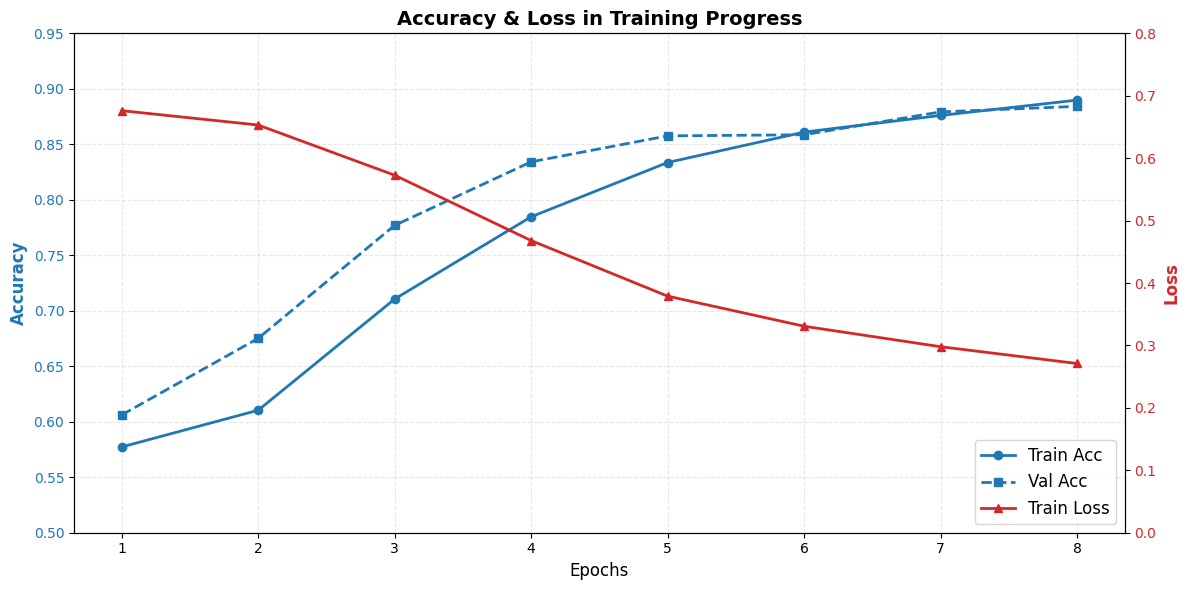

In [44]:
epochs = range(1, 9)
train_acc = [0.5773, 0.6104, 0.7106, 0.7847, 0.8336, 0.8610, 0.8760, 0.8898]
val_acc   = [0.6062, 0.6752, 0.7770, 0.8342, 0.8576, 0.8586, 0.8792, 0.8842]
train_loss= [0.6761, 0.6531, 0.5727, 0.4680, 0.3790, 0.3308, 0.2980, 0.2711]
# 注：由于之前的代码忘记在训练时随时保存acc和loss了，上述数据由截屏得来

fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'tab:blue'
ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('Accuracy', color=color, fontsize=12, fontweight='bold')
ax1.plot(epochs, train_acc, 'o-', color=color, label='Train Acc', linewidth=2)
ax1.plot(epochs, val_acc, 's--', color=color, label='Val Acc', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.3)
ax1.set_ylim([0.5, 0.95])

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Loss', color=color, fontsize=12, fontweight='bold')
ax2.plot(epochs, train_loss, '^-', color=color, label='Train Loss', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim([0, 0.8])

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right', fontsize=12)

plt.title('Accuracy & Loss in Training Progress', fontsize=14, fontweight='bold')
plt.xticks(epochs)
plt.tight_layout()
plt.show()